In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import zipfile
import json
from tqdm import tqdm

from experiments.problem_instance.problem_instance import ProblemInstance
from experiments.benchmark.benchmark import Benchmark
from experiments.benchmark.approaches import DatabaseWiseApproach

In [2]:
def get_problem_instance_with_ground_truth(openmlid, data_seed, num_possible_ensemble_members, validation_size, folder="../problem_instance/problem_instances"):
    # load ground truth
    with zipfile.ZipFile(f"{folder}/{openmlid}_{data_seed}_{num_possible_ensemble_members}_{validation_size}.json.zip", 'r') as zip_ref:
        json_filename = zip_ref.namelist()[0]
        with zip_ref.open(json_filename) as json_file:
            d = json.load(json_file)
            if "validation_instances_per_class" in d: # this is a relict not supported anymore
                d.pop("validation_instances_per_class")
            
            scores_iid = np.array(d.pop("scores_iid"))
            scores_cond = np.array(d.pop("scores_cond"))

            d["true_means_for_iid_case"] = scores_iid.mean(axis=0)
            d["true_vars_for_iid_case"] = scores_iid.var(axis=0)
            d["true_means_for_cond_case"] = scores_cond.mean(axis=0)
            d["true_vars_for_cond_case"] = scores_cond.var(axis=0)

            pi = ProblemInstance.from_dict(d)
            assert pi._true_means_for_iid_case is not None
            if pi._true_means_for_iid_case.shape == (len(pi.n_checkpoints), len(pi.t_checkpoints)):
                pi._true_means_for_iid_case = pi._true_means_for_iid_case.mean(axis=0)
            assert pi._true_means_for_iid_case.shape == (len(pi.t_checkpoints), )
            assert pi._true_vars_for_iid_case is not None
            assert pi._true_vars_for_iid_case.shape == (len(pi.n_checkpoints), len(pi.t_checkpoints))
            assert pi._true_means_for_cond_case is not None
            assert pi._true_means_for_cond_case.shape == (len(pi.t_checkpoints), )
            assert pi._true_vars_for_cond_case is not None
            assert pi._true_vars_for_cond_case.shape == (len(pi.t_checkpoints), )
            pi._load_data()
    return pi

pi = get_problem_instance_with_ground_truth(openmlid=1049, data_seed=0, num_possible_ensemble_members=8, validation_size=8)

In [3]:
param = "V[Z_nt|D_val]"
d_threshold_for_number_of_samples_to_exclude_param = [10**2, 10**3, 10**4, 10**5]
approaches = [
    DatabaseWiseApproach(
        estimated_parameters=[param],
        threshold_for_number_of_samples_to_exclude_param=threshold_for_number_of_samples_to_exclude_param
    )
    for threshold_for_number_of_samples_to_exclude_param in d_threshold_for_number_of_samples_to_exclude_param
]

named_approaches = {k: a for k, a in zip(d_threshold_for_number_of_samples_to_exclude_param, approaches)}

num_seeds = 1
num_rounds = 10**2
hists = {k: np.zeros((num_seeds, num_rounds)) for k in named_approaches.keys()}

for sequence_seed in range(num_seeds):

    benchmark = Benchmark(
        captured_parameters=[param],
        problem_instance=pi,
        ensemble_sequence_seed=sequence_seed
    )

    
    benchmark.reset(approaches=named_approaches)
    
    for round in tqdm(range(num_rounds)):
        benchmark.step()
        for k, a in named_approaches.items():
            hists[k][sequence_seed, round] = a.estimate_performance_var_in_conditional_setup(t=10**3).item()
            #hists[k][sequence_seed, round] = a.estimate_performance_mean_in_conditional_setup(t=10**3).item()

100%|██████████| 100/100 [00:22<00:00,  4.36it/s]


[1.44115614e-03 6.30138771e-04 1.10228726e-04 1.06345624e-05
 1.05903111e-06]


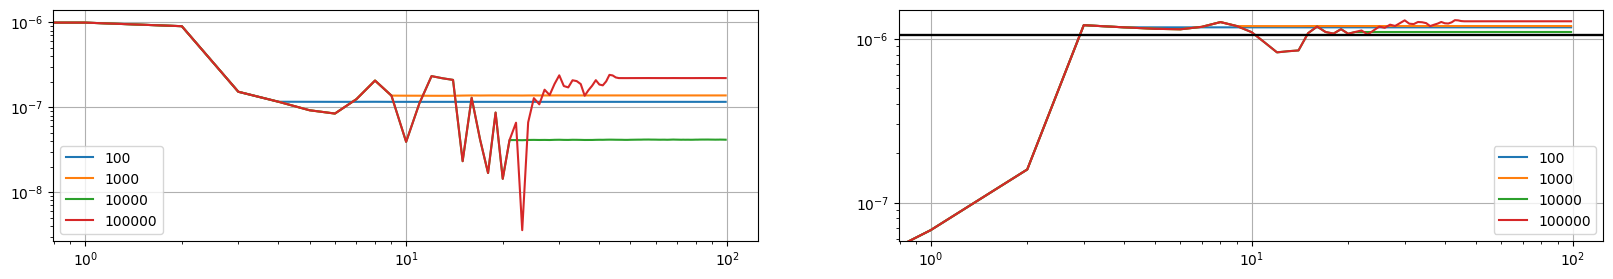

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(20, 3))
print(pi.vars_cond)
for a_name, a_hist in hists.items():
    mae = np.abs(a_hist - pi.vars_cond[-1])
    mae_mean = mae.mean(axis=0)
    mae_std = mae.std(axis=0)
    budget = range(mae.shape[1])

    ax = axs[0]
    ax.plot(budget, mae_mean, label=a_name)
    ax.fill_between(budget, mae_mean - mae_std, mae_mean + mae_std, alpha=0.2)

    ax = axs[1]
    mean = a_hist.mean(axis=0)
    std = a_hist.std(axis=0)
    ax.plot(mean, label=a_name)
    ax.fill_between(budget, mean - std, mean + std, alpha=0.2)
    ax.axhline(pi.vars_cond[-1], color="black")

for ax in axs:
    ax.legend()
    ax.grid()
    ax.set_xscale("log")
    ax.set_yscale("log")
plt.show()